[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/28_pre_traitement.ipynb)



# Le prétraitement d'un vrai projet

L'EDA du notebook 27 a donné la carte du dataset COVID. Ce notebook fait le voyage :
transformer ces données brutes, trouées, textuelles, en quelque chose qu'un modèle
peut apprendre puis entraîner un premier modèle et l'évaluer.

C'est le moment où tout se réunit : la sélection de colonnes de l'EDA, l'encodage,
l'imputation, le train/test, la modélisation, l'évaluation. Un cycle complet.

## Le plan

| Section | L'étape |
|---|---|
| 1 | Sélectionner les colonnes utiles (issu de l'EDA) |
| 2 | Séparer train/test avant tout nettoyage |
| 3 | Encoder les variables textuelles |
| 4 | Feature engineering : créer « est malade » |
| 5 | Imputer les valeurs manquantes |
| 6 | Le preprocessing en une fonction |
| 7 | Modéliser et évaluer |
| 8 | Améliorer : pipeline et sélection |

## Trois principes annoncés

Le train/test se fait avant tout nettoyage sinon les décisions voient le test.

L'encodage transforme le texte en nombres via un dictionnaire `map`.

Et on construit tout en fonctions, pour appliquer exactement le même
traitement au train et au test.

Prérequis : le notebook 27 (EDA), et 22.x (prétraitement).

## Chargement

On repart du dataset COVID, comme au notebook 27.

In [20]:
from google.colab import files
uploaded = files.upload() # dataset.xlsx

Saving dataset.xlsx to dataset (1).xlsx


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_row', 111)
pd.set_option('display.max_columns', 111)

data = pd.read_excel('dataset.xlsx')
df = data.copy()
print('dimensions :', df.shape)

dimensions : (5644, 111)


## 1. Sélectionner les colonnes utiles

L'EDA a montré que la plupart des colonnes sont trop vides. On garde les deux blocs
exploitables sang et viral plus les variables clés.

In [22]:
missing_rate = df.isna().sum() / df.shape[0]

blood_columns = list(df.columns[(missing_rate < 0.9) & (missing_rate > 0.88)])
viral_columns = list(df.columns[(missing_rate < 0.88) & (missing_rate > 0.75)])

key_columns = ['Patient age quantile', 'SARS-Cov-2 exam result']

print('sang :', len(blood_columns), 'colonnes')
print('viral :', len(viral_columns), 'colonnes')

sang : 14 colonnes
viral : 19 colonnes


Le piège de la concaténation. `df.columns[...]` renvoie un objet `Index`, pas
une liste. Additionner un `Index` avec une liste échoue. La solution est
d'envelopper chaque sélection dans `list(...)` ce qui est fait ci-dessus.

In [23]:
df = df[key_columns + blood_columns + viral_columns]
print('après sélection :', df.shape)
df.head()

après sélection : (5644, 35)


,Patient age quantile,SARS-Cov-2 exam result,Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,Mean corpuscular hemoglobin concentration (MCHC),Leukocytes,Basophils,Mean corpuscular hemoglobin (MCH),Eosinophils,Mean corpuscular volume (MCV),Monocytes,Red blood cell distribution width (RDW),Respiratory Syncytial Virus,Influenza A,Influenza B,Parainfluenza 1,CoronavirusNL63,Rhinovirus/Enterovirus,Coronavirus HKU1,Parainfluenza 3,Chlamydophila pneumoniae,Adenovirus,Parainfluenza 4,Coronavirus229E,CoronavirusOC43,Inf A H1N1 2009,Bordetella pertussis,Metapneumovirus,Parainfluenza 2,"Influenza B, rapid test","Influenza A, rapid test"
0,13,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17,negative,0.236515,-0.02234,-0.517413,0.010677,0.102004,0.318366,-0.95079,-0.09461,-0.223767,-0.292269,1.482158,0.166192,0.357547,-0.625073,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,negative,negative
2,8,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,15,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,not_detected,not_detected,not_detected,not_detected,not_detected,detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,not_detected,NaN,NaN


On passe de 111 colonnes à seulement celles qui portent de l'information. C'est le
fruit direct de l'EDA : l'exploration a identifié quoi garder, le prétraitement
l'applique.

## 2. Séparer train et test AVANT tout nettoyage

C'est le principe méthodologique du notebook. On sépare d'abord, on nettoie ensuite séparément sur chaque ensemble.

In [24]:
from sklearn.model_selection import train_test_split

trainset, testset = train_test_split(df, test_size=0.2, random_state=0)

print('train :', trainset.shape)
print('test :', testset.shape)

train : (4515, 35)
test : (1129, 35)


Pourquoi séparer si tôt. Toute décision de nettoyage quelle valeur imputer,
quelles lignes retirer apprend quelque chose des données. Si on nettoyait avant
de séparer, ces décisions « verraient » le test, et l'évaluation serait faussée.
C'est la fuite d'information des notebooks 21 et 22.

En séparant d'abord, le test reste un vrai inconnu, nettoyé avec les seules règles
tirées du train.

### Vérifier l'équilibre

In [25]:
print('Train :')
print(trainset['SARS-Cov-2 exam result'].value_counts())
print('Test :')
print(testset['SARS-Cov-2 exam result'].value_counts())

Train :
SARS-Cov-2 exam result
negative    4068
positive     447
Name: count, dtype: int64
Test :
SARS-Cov-2 exam result
negative    1018
positive     111
Name: count, dtype: int64


On retrouve le déséquilibre de l'EDA : environ 90 % de négatifs dans les deux
ensembles. `train_test_split` a réparti les positifs proportionnellement. Ce
déséquilibre dictera le choix des métriques d'évaluation.

## 3. Encoder les variables textuelles

Les tests viraux et la cible sont du texte (`positive`, `detected`...). Un modèle
veut des nombres. On les convertit avec un dictionnaire.

In [26]:
def encodage(df):
    code = {
        'negative': 0,
        'positive': 1,
        'not_detected': 0,
        'detected': 1,
    }
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].map(code)
    return df

`map` remplace chaque valeur textuelle par son code numérique. Comme toutes les
variables qualitatives sont binaires (l'EDA l'a montré), un simple 0/1 suffit pas besoin de `OneHotEncoder`.

On en fait une fonction : c'est essentiel pour appliquer exactement le même
encodage au train et au test. Une fonction garantit un traitement identique des
deux côtés.

## 4. Feature engineering : créer « est malade »

On enrichit les données avec une variable construite l'idée testée à l'EDA.

In [27]:
def feature_engineering(df):
    df['est malade'] = df[viral_columns].sum(axis=1) >= 1
    df = df.drop(viral_columns, axis=1)
    return df

L'idée. Plutôt que de garder chaque test viral séparément, on crée une
variable : « ce patient a-t-il au moins un virus détecté ? ». La somme des colonnes
virales (encodées en 0/1) vaut au moins 1 si un virus est présent.

Puis on retire les colonnes virales d'origine, remplacées par ce résumé. C'est
le feature engineering du notebook 22 : condenser plusieurs variables en une, plus
informative et plus compacte.

C'est un apport clé du corrigé de Guillaume par rapport à une approche naïve :
transformer l'information brute en une variable qui a du sens médical.

## 5. Imputer les valeurs manquantes

Le dataset est troué. Deux stratégies, qu'on compare.

In [28]:
def imputation(df):
    return df.dropna(axis=0)

La stratégie simple : `dropna`. On supprime les lignes incomplètes. Sur ce
jeu, comme les blocs sang et viral sont renseignés ensemble, il reste assez de
lignes complètes pour travailler.

L'alternative : `fillna`. On pourrait boucher les trous plutôt que supprimer
les lignes :

```python
def imputation(df):
    return df.fillna(-999)
```

Remplir par une valeur hors plage (-999) permet de garder toutes les lignes le modèle apprend à traiter -999 comme « donnée absente ». Utile quand `dropna`
supprimerait trop de données.

Le choix dépend du résultat. On commence par `dropna` (plus simple), et si le
modèle manque de données, on passe à `fillna`. C'est une décision qu'on tranche en
comparant les performances.

## 6. Le preprocessing en une fonction

On assemble les trois étapes en une seule fonction, qui produit `X` et `y`.

In [29]:
def preprocessing(df):
    df = encodage(df)
    df = feature_engineering(df)
    df = imputation(df)

    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']

    print(y.value_counts())
    return X, y

In [30]:
X_train, y_train = preprocessing(trainset)
X_test, y_test = preprocessing(testset)

SARS-Cov-2 exam result
0    422
1     65
Name: count, dtype: int64
SARS-Cov-2 exam result
0    95
1    16
Name: count, dtype: int64


Pourquoi une fonction unique est cruciale. On applique exactement le même
traitement au train et au test, en un seul appel. Aucun risque d'oublier une étape
ou de traiter les deux différemment.

Et surtout : le test passe par le même preprocessing, mais après avoir été
séparé. Le nettoyage du test ne contamine jamais le train. La discipline des
notebooks 21-22, appliquée à un vrai projet.

Le `print(y.value_counts())` affiche l'équilibre après nettoyage utile pour
vérifier qu'on garde assez de positifs.

## 7. Modéliser et évaluer

Un premier modèle simple, pour établir une base de référence.

In [31]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=0)

### La procédure d'évaluation

Vu le déséquilibre, l'exactitude (accuracy) serait trompeuse prédire « négatif »
partout donnerait 90 %. On utilise des métriques adaptées.

In [32]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

def evaluation(model):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))

    N, train_score, val_score = learning_curve(
        model, X_train, y_train,
        cv=4, scoring='f1',
        train_sizes=np.linspace(0.1, 1, 10))

    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()
    plt.show()

[[87  8]
 [ 9  7]]
              precision    recall  f1-score   support

           0       0.91      0.92      0.91        95
           1       0.47      0.44      0.45        16

    accuracy                           0.85       111
   macro avg       0.69      0.68      0.68       111
weighted avg       0.84      0.85      0.84       111



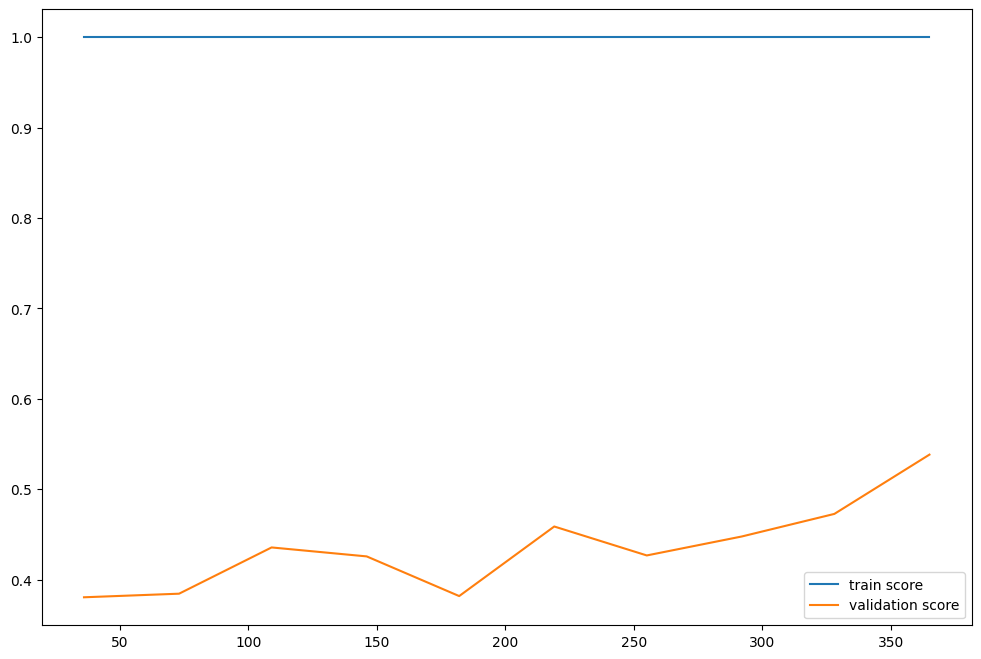

In [33]:
evaluation(model)

Les outils d'évaluation, adaptés au déséquilibre.

La matrice de confusion (notebook 21) montre le détail : vrais/faux
positifs/négatifs. Sur un problème médical, distinguer un COVID raté (faux négatif)
d'une fausse alerte (faux positif) est capital.

Le classification_report donne précision, rappel et f1-score par classe. Le
`scoring='f1'` de la learning_curve est le bon choix ici : le f1 équilibre
précision et rappel, contrairement à l'accuracy qui masquerait la classe rare.

La courbe d'apprentissage (notebook 21) révèle le comportement du modèle.

Le constat attendu : surapprentissage. Un arbre de décision sans limite
mémorise le train score d'entraînement au plafond, score de validation bien plus
bas. L'écart entre les deux courbes est le surapprentissage du notebook 21. C'est
notre point de départ à améliorer.

## 8. Améliorer : pipeline et sélection

Deux leviers pour faire mieux : un meilleur modèle (Random Forest, notebook 25) et
un pipeline avec sélection de variables (notebooks 22-23).

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_classif

model_1 = RandomForestClassifier(random_state=0)

model_2 = make_pipeline(
    PolynomialFeatures(2),
    SelectKBest(f_classif, k=10),
    RandomForestClassifier(random_state=0))

`model_1` un Random Forest, plus robuste qu'un arbre seul (notebook 25). Le
vote de nombreux arbres réduit le surapprentissage.

`model_2` un pipeline complet : `PolynomialFeatures` crée des interactions
entre variables, `SelectKBest` garde les 10 plus liées à la cible (notebook 23),
puis le Random Forest classe. Tout enchaîné sans fuite.

Le `f_classif` remplace le `chi2` du notebook 23 : il convient aux variables
continues (les taux sanguins), là où le chi² exige des valeurs positives.

[[92  3]
 [12  4]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92        95
           1       0.57      0.25      0.35        16

    accuracy                           0.86       111
   macro avg       0.73      0.61      0.64       111
weighted avg       0.84      0.86      0.84       111



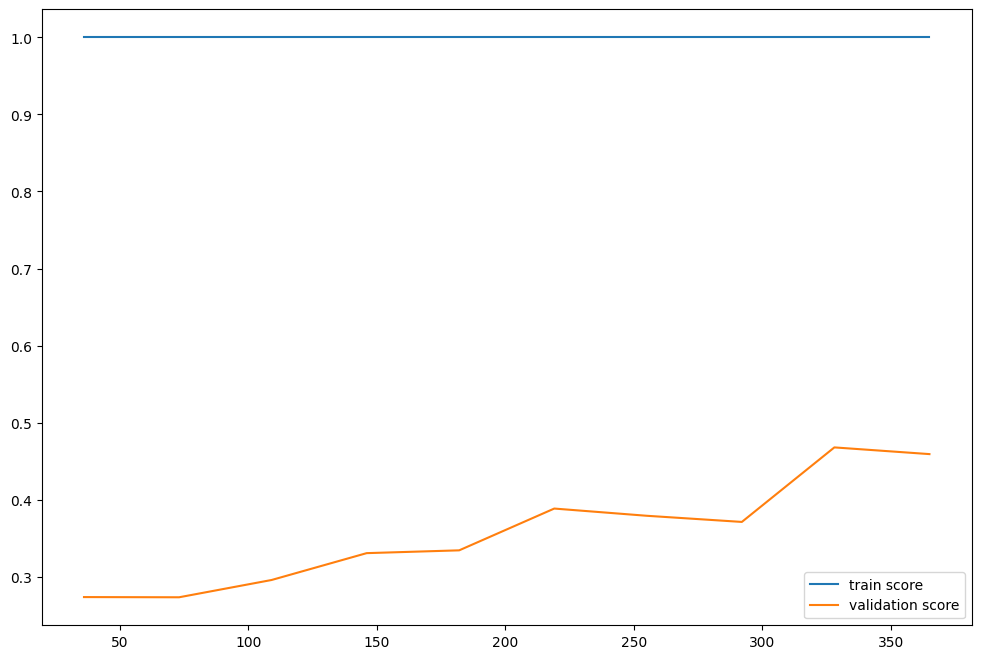

In [36]:
evaluation(model_1)

/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


[[91  4]
 [10  6]]
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        95
           1       0.60      0.38      0.46        16

    accuracy                           0.87       111
   macro avg       0.75      0.67      0.70       111
weighted avg       0.86      0.87      0.86       111



/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/usr/local/lib/python3.13/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [0] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/pyt

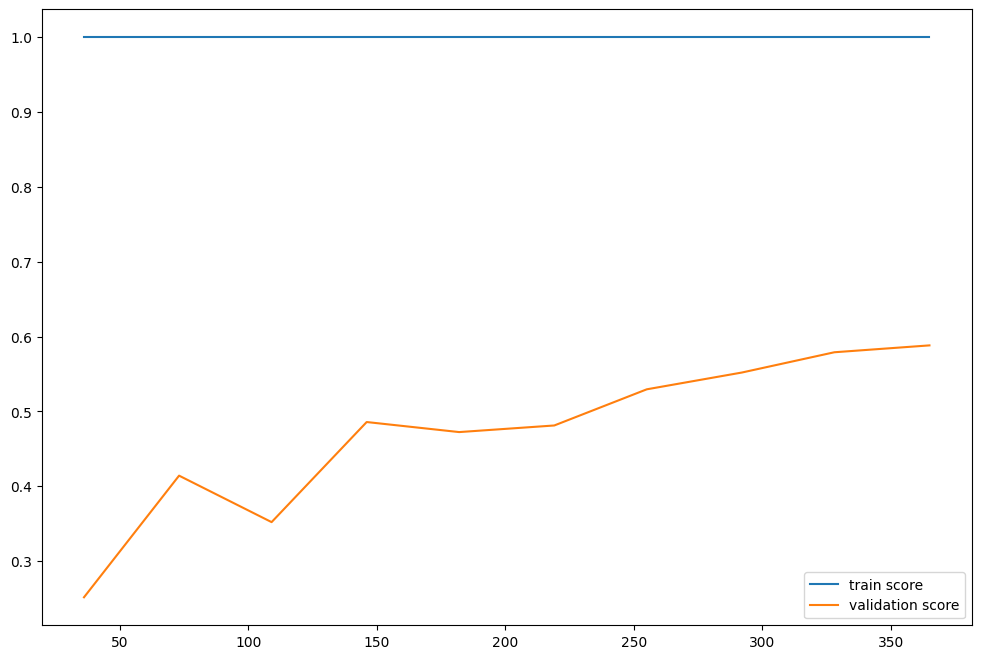

In [37]:
evaluation(model_2)

On compare les courbes d'apprentissage. Le Random Forest réduit généralement
l'écart train/validation par rapport à l'arbre seul. Le pipeline avec sélection
peut encore aider en retirant les variables bruitées.

### L'importance des variables

Le Random Forest révèle quelles variables comptent le plus un lien direct avec
l'EDA et le notebook 23.

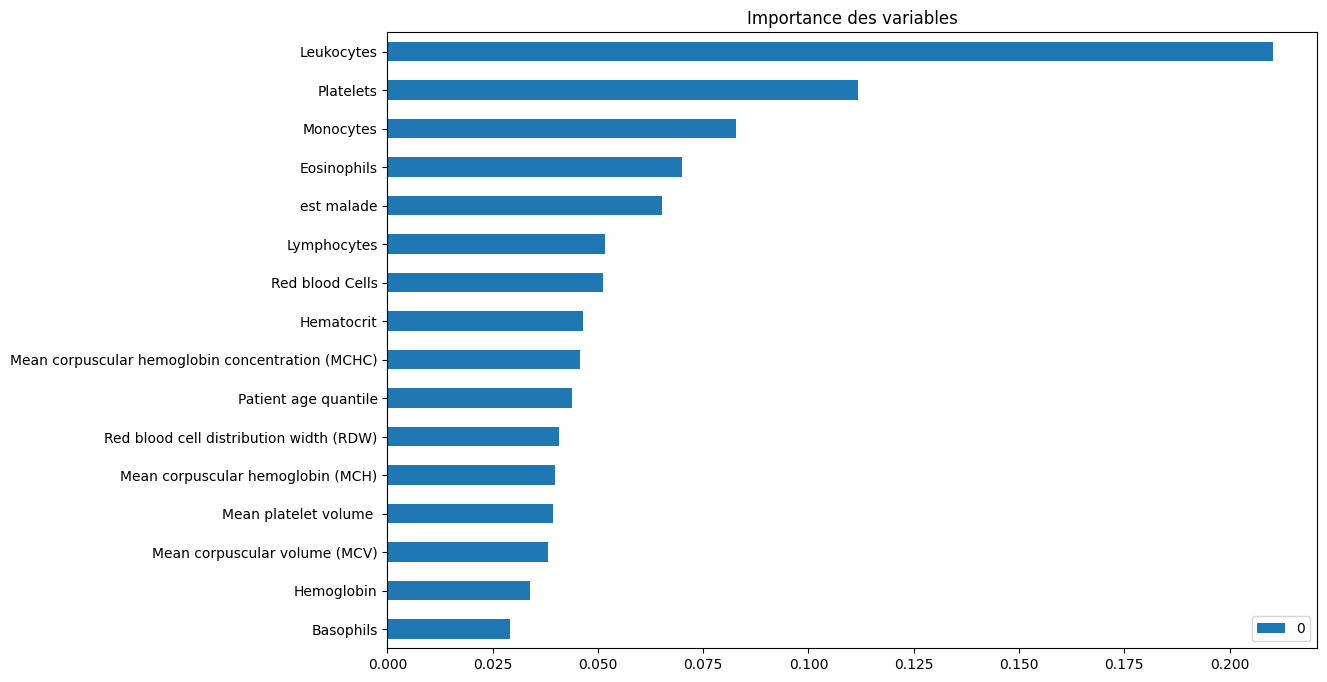

In [38]:
model_1.fit(X_train, y_train)

pd.DataFrame(model_1.feature_importances_, index=X_train.columns) \
    .sort_values(by=0, ascending=True) \
    .plot.barh(figsize=(12, 8))
plt.title('Importance des variables')
plt.show()

`feature_importances_` classe les variables par leur contribution aux décisions de
la forêt. On retrouve normalement les taux sanguins suspectés à l'EDA Leukocytes,
Monocytes, Platelets parmi les plus importants.

La boucle est bouclée. L'EDA (notebook 27) avait repéré ces variables à l'œil,
le test de Student les avait confirmées, et maintenant le modèle les désigne comme
les plus utiles. Trois approches indépendantes qui convergent le signe d'une
analyse solide.

## 9. Mémo : le cycle complet d'un projet

### Les étapes, dans l'ordre

1. Charger et copier les données.
2. Sélectionner les colonnes utiles (d'après l'EDA).
3. Séparer train/test avant tout nettoyage.
4. Encoder le texte en nombres.
5. Feature engineering créer des variables utiles.
6. Imputer les manques (`dropna` ou `fillna`).
7. Tout mettre en fonctions (train et test identiques).
8. Modéliser et évaluer (métriques adaptées au déséquilibre).
9. Améliorer meilleur modèle, pipeline, sélection.

### Le principe d'or

Le train/test se fait au tout début. Chaque nettoyage apprend des données
le faire avant de séparer contamine le test.

### Les outils

```python
trainset, testset = train_test_split(df, test_size=0.2, random_state=0)
df[col] = df[col].map({'negative': 0, 'positive': 1}) # encodage
df['est malade'] = df[viral].sum(axis=1) >= 1  # feature engineering
df.dropna(axis=0) # ou df.fillna(-999)  # imputation
classification_report(y_test, ypred) # évaluation
learning_curve(model, X, y, scoring='f1') # diagnostic
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `list()` oublié sur `df.columns[...]` | erreur de concaténation |
| Nettoyer avant de séparer | fuite d'information |
| Accuracy sur données déséquilibrées | métrique trompeuse |
| Traiter train et test différemment | incohérence, d'où les fonctions |
| Arbre sans limite | surapprentissage |

## 10. Exercices

**Exercice 1**

Compare les deux stratégies d'imputation `dropna` et `fillna(-999)` sur le même
modèle. Laquelle garde le plus de lignes ? Laquelle donne le meilleur f1-score ?
Explique le compromis.

**Exercice 2**

Sur le modèle final, affiche la matrice de confusion et interprète chaque case.
Combien de COVID sont ratés (faux négatifs) ? Pourquoi, dans un contexte médical,
le rappel (recall) importe-t-il plus que la précision ?

**Exercice 3**

Un camarade fait son `train_test_split` après l'encodage et l'imputation, sur
le dataset entier. Explique quelle fuite cela crée, et pourquoi son score de test
sera trop optimiste par rapport à la réalité.

## Pour continuer

Tu viens de réaliser un projet de bout en bout sur des données médicales réelles exploration, prétraitement, modélisation, évaluation. C'est exactement le travail
d'un data scientist.

Le notebook suivant approfondira la modélisation : optimiser les hyperparamètres
par `GridSearchCV`, tester plusieurs modèles, et pousser la performance aussi loin
que possible sur ce dataset. Le prétraitement en fonctions que tu as construit ici
restera la base sur laquelle tout repose.

In [39]:
# Exercice 1

In [40]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

# On garde encodage et feature_engineering identiques,
# on ne change que l'imputation

def preprocessing_variant(df, strategie):
    df = encodage(df)
    df = feature_engineering(df)
    if strategie == 'dropna':
        df = df.dropna(axis=0)
    else:  # fillna
        df = df.fillna(-999)
    X = df.drop('SARS-Cov-2 exam result', axis=1)
    y = df['SARS-Cov-2 exam result']
    return X, y

for strategie in ['dropna', 'fillna']:
    X_train, y_train = preprocessing_variant(trainset.copy(), strategie)
    X_test, y_test = preprocessing_variant(testset.copy(), strategie)

    model = RandomForestClassifier(random_state=0)
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)

    print(f'{strategie:<8} : {X_train.shape[0]:>4} lignes train, '
          f'f1 = {f1_score(y_test, ypred):.3f}')

dropna   :  487 lignes train, f1 = 0.348
fillna   : 4515 lignes train, f1 = 0.068


In [41]:
def imputation_avancee(df):
    df['is_na'] = df['Leukocytes'].isna() # trace les trous
    return df.fillna(-999)

In [42]:
# Exercice 2

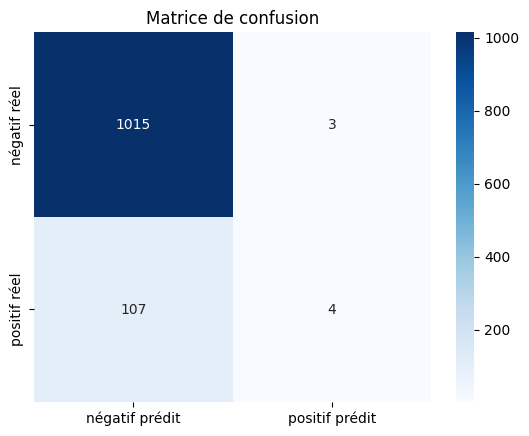

              precision    recall  f1-score   support

           0       0.90      1.00      0.95      1018
           1       0.57      0.04      0.07       111

    accuracy                           0.90      1129
   macro avg       0.74      0.52      0.51      1129
weighted avg       0.87      0.90      0.86      1129



In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model = RandomForestClassifier(random_state=0)
model.fit(X_train, y_train)
ypred = model.predict(X_test)

cm = confusion_matrix(y_test, ypred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['négatif prédit', 'positif prédit'],
            yticklabels=['négatif réel', 'positif réel'])
plt.title('Matrice de confusion')
plt.show()

print(classification_report(y_test, ypred))

In [44]:
# Exercice 3

In [47]:
# Ce que fait le camarade (Faux)
df_encode = encodage(df.copy())
df_impute = df_encode.fillna(df_encode.mean()) # moyenne sur TOUT le dataset
train, test = train_test_split(df_impute, test_size=0.2, random_state=0)
# -> le test a été bouché avec une moyenne qui l'incluait

In [48]:
# La bonne façon
train, test = train_test_split(df, test_size=0.2, random_state=0)
X_train, y_train = preprocessing(train) # moyenne calculée sur le train seul
X_test, y_test = preprocessing(test) # test bouché avec les stats du train

SARS-Cov-2 exam result
0    422
1     65
Name: count, dtype: int64
SARS-Cov-2 exam result
0    95
1    16
Name: count, dtype: int64
